In [1]:
from langchain_openai import ChatOpenAI
import os
from langchain_google_genai import ChatGoogleGenerativeAI

base_url= os.getenv("AICREDITS_BASE_URL")
api_key = os.getenv("AICREDITS_API_KEY")

In [25]:
#from langchain_openai import ChatOpenAI

# Initialize the chat model using the OpenAI interface configured for AICredits
llm = ChatOpenAI(
    model="google/gemini-2.0-flash",
    api_key=api_key,
    base_url=base_url,
    temperature=2.0
)

# Test the model
response = llm.invoke("Hello!")
print(response.content)


Hello! How can I help you today?


In [ ]:
#!pip install -U ddgs

In [3]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()
print(f"Tool Name: {search.name}")
print(f"Tool Descriptiion: {search.description}")
print(f"Tool's arg schema: {search.args_schema}")

Tool Name: duckduckgo_search
Tool Descriptiion: A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.
Tool's arg schema: <class 'langchain_community.tools.ddg_search.tool.DDGInput'>


C:\Users\Shivachetan Ulavi\AppData\Local\Temp\ipykernel_20856\1704625643.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [4]:
from langchain_community.tools.ddg_search.tool import DDGInput
print(DDGInput.__fields__)

{'query': FieldInfo(annotation=str, required=True, description='search query to look up')}


C:\Users\Shivachetan Ulavi\AppData\Local\Temp\ipykernel_20856\808160465.py:2: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  print(DDGInput.__fields__)


In [5]:
query = "What is the weather in Munich like tomorrow?"
search_input = DDGInput(query=query)
result = search.invoke(search_input.dict())
print(result)

C:\Users\Shivachetan Ulavi\AppData\Local\Temp\ipykernel_20856\2711840498.py:3: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  result = search.invoke(search_input.dict())


Sep 6, 2026 · Everything you need to know about tomorrow's weather in Munich, Bavaria, Germany. High/Low, Precipitation Chances, Sunrise/Sunset, and tomorrow's Temperature History. 1 day ago · Get the latest hourly weather updates for Munich tomorrow. Detailed forecast including temperature, wind, rain, snow, and UV index. Stay informed about tomorrow's weather conditions in Munich. Today's and tonight's professional weather forecast for Munich. Precipitation radar, HD satellite images, and current weather warnings, hourly temperature, chance of rain, and sunshine hours. Sep 6, 2026 · Munich, Germany - Detailed weather forecast for tomorrow. Hourly forecast for tomorrow - including weather conditions, temperature, pressure, humidity, precipitation, dewpoint, wind, visibility, and UV index data. 10 hours ago · The Long-range 12 day forecast also includes detail for Munich weather today. Live weather reports from Munich weather stations and weather warnings that include risk of thunder, 

In [19]:
# 1. Bind the search tool to your ChatOpenAI instance
llm_with_tools = llm.bind_tools([search])

# 2. Invoke the bound model
resut = llm_with_tools.invoke(query)

# 3. Check the tool calls generated by the model
print(resut.tool_calls)


[{'name': 'duckduckgo_search', 'args': {'query': 'weather in Munich tomorrow'}, 'id': 'call_duckduckgo_search_0', 'type': 'tool_call'}]


In [22]:
from langgraph.prebuilt import create_react_agent

C:\Users\Shivachetan Ulavi\AppData\Local\Temp\ipykernel_20856\844614583.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


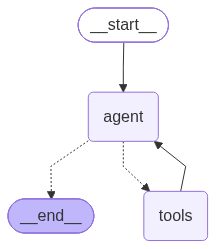

In [26]:
from IPython.display import Image, display

agent = create_react_agent(
    model=llm,
    tools=[search],
    prompt="Always use a duckduckgo_search tool for queries that require a fresh information"
)

display(Image(agent.get_graph().draw_mermaid_png()))

In [27]:
for event in agent.stream({"messages":[("user", query)]}):
    update = event.get("agent", event.get("tools", {}))
    for message in update.get("messages",[]):
        message.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_duckduckgo_search_0)
 Call ID: call_duckduckgo_search_0
  Args:
    query: weather in Munich tomorrow
================================= Tool Message =================================
Name: duckduckgo_search

16 hours ago - As of 07:00 PM 04 September 2026, there is a 2% chance of rainfall in Munich later today around 2026-09-04 19:00. Current precipitation is 0 mm. Residents are advised to carry an umbrella before heading out. 5. What is the monthly weather forecast for Munich in September 2026? March 31, 2026 - The wind in Munich is expected to blow at 15 km/h. This could affect outdoor activities, so plan accordingly. Given the forecast of 4 °C with a 88% chance of rain, we advise checking our "What to wear tomorrow" section for recommendations. 3 days ago - This page provides the current weather forecast for Munich, Bavaria, Germany, including hourly conditions, a 1

using third party API by wrapping it a tool

In [28]:
api_spec = """
openapi: 3.0.0
info:
  title: Frankfurter Currency Exchange API
  version: v1
  description: API for retrieving currency exchange rates. Pay attention to the base currency and change it if needed.

servers:
  - url: https://api.frankfurter.dev/v1

paths:
  /v1/{date}:
    get:
      summary: Get exchange rates for a specific date.
      parameters:
        - in: path
          name: date
          schema:
            type: string
            pattern: '^\d{4}-\d{2}-\d{2}$' # YYYY-MM-DD format
          required: true
          description: The date for which to retrieve exchange rates.  Use YYYY-MM-DD format.  Example: 2009-01-04
        - in: query
          name: symbols
          schema:
            type: string
          description: Comma-separated list of currency symbols to retrieve rates for. Example: GBP,USD,EUR

  /v1/latest:
    get:
      summary: Get the latest exchange rates.
      parameters:
        - in: query
          name: symbols
          schema:
            type: string
          description: Comma-separated list of currency symbols to retrieve rates for. Example: CHF,GBP
        - in: query
          name: base
          schema:
            type: string
          description: The base currency for the exchange rates. If not provided, EUR is used as a base currency. Example: USD
"""

In [30]:
from langchain_community.agent_toolkits.openapi.toolkit import RequestsToolkit
from langchain_community.utilities.requests import TextRequestsWrapper

toolkit = RequestsToolkit(
    requests_wrapper=TextRequestsWrapper(headers = {}),
    allow_dangerous_requests=True,
)

for tool in toolkit.get_tools():
    print(tool.name)

requests_get
requests_post
requests_patch
requests_put
requests_delete


In [31]:
system_message = (
    "You're given the API spec:\n{api_spec}\n"
    "Use the API to answer users' queries if possible. "
)

agent2 = create_react_agent(llm, toolkit.get_tools(), prompt= system_message.format(api_spec=api_spec))

query = "What is the Indian Rupee to US Dollar exchange rate?"

events = agent2.stream(
    {"messages": [("user", query)]},
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

C:\Users\Shivachetan Ulavi\AppData\Local\Temp\ipykernel_20856\327737700.py:6: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent2 = create_react_agent(llm, toolkit.get_tools(), prompt= system_message.format(api_spec=api_spec))


================================ Human Message =================================

What is the Indian Rupee to US Dollar exchange rate?
================================== Ai Message ==================================
Tool Calls:
  requests_get (call_requests_get_0)
 Call ID: call_requests_get_0
  Args:
    url: https://api.frankfurter.dev/v1/latest?base=USD&symbols=INR
================================= Tool Message =================================
Name: requests_get

{"amount":1.0,"base":"USD","date":"2026-09-04","rates":{"INR":94.49}}
================================== Ai Message ==================================

The current exchange rate is 1 USD = 94.49 INR.
